## Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
base = '/content/drive/MyDrive/deepfake_project/dataset'
for split in ['train', 'valid', 'test']:
    for cls in ['real', 'fake']:
        path = os.path.join(base, split, cls)
        count = len(os.listdir(path))
        print(f"{split}/{cls}: {count} images")

  ##  Copy Dataset to Colab

In [ ]:
import shutil

src = '/content/drive/MyDrive/deepfake_project/dataset'
dst = '/content/dataset'

print("Copying dataset to local disk... (takes 1-2 mins)")
shutil.copytree(src, dst)
print("Done! Dataset is now local.")

# Verify
for split in ['train', 'valid', 'test']:
    for cls in ['real', 'fake']:
        path = os.path.join(dst, split, cls)
        print(f"{split}/{cls}: {len(os.listdir(path))} images")

## Install Libraries

In [6]:
!pip install grad-cam streamlit pyngrok -q

In [7]:
import os, numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)  # Must say cuda

Using: cuda


## **Data Loaders with FFT**

In [8]:
DATA_DIR = '/content/dataset'

class AddFFTChannel:
    def __call__(self, tensor):
        gray = tensor.mean(dim=0)
        fft = torch.fft.fft2(gray)
        magnitude = torch.log(torch.abs(fft) + 1e-8)
        magnitude = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min())
        return torch.cat([tensor, magnitude.unsqueeze(0)], dim=0)

fft_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
    AddFFTChannel(),
])

train_data = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=fft_transform)
valid_data = datasets.ImageFolder(os.path.join(DATA_DIR, 'valid'), transform=fft_transform)
test_data  = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'),  transform=fft_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False, num_workers=2)

print("Classes:", train_data.classes)
print(f"Train: {len(train_data)} | Valid: {len(valid_data)} | Test: {len(test_data)}")

Classes: ['fake', 'real']
Train: 1600 | Valid: 200 | Test: 200


## **Model**

In [9]:
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Modify first conv to accept 4 channels (3 RGB + 1 FFT)
old_conv = model.features[0][0]
new_conv = nn.Conv2d(4, old_conv.out_channels,
                     kernel_size=old_conv.kernel_size,
                     stride=old_conv.stride,
                     padding=old_conv.padding,
                     bias=False)
with torch.no_grad():
    new_conv.weight[:, :3] = old_conv.weight
    new_conv.weight[:, 3]  = old_conv.weight[:, 0]

model.features[0][0] = new_conv
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
model = model.to(device)
print("Model ready")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 83.1MB/s]


Model ready


## **Training**

Epoch 1/10 | Train Loss: 0.6099 | Val Loss: 0.5216 | Val Acc: 0.7700
  - Best model saved
Epoch 2/10 | Train Loss: 0.3862 | Val Loss: 0.3422 | Val Acc: 0.8500
  - Best model saved
Epoch 3/10 | Train Loss: 0.2018 | Val Loss: 0.2324 | Val Acc: 0.9000
  - Best model saved
Epoch 4/10 | Train Loss: 0.1180 | Val Loss: 0.2253 | Val Acc: 0.8950
  - Best model saved
Epoch 5/10 | Train Loss: 0.0765 | Val Loss: 0.2145 | Val Acc: 0.9100
  - Best model saved
Epoch 6/10 | Train Loss: 0.0587 | Val Loss: 0.2297 | Val Acc: 0.9100
Epoch 7/10 | Train Loss: 0.0456 | Val Loss: 0.1997 | Val Acc: 0.9150
  - Best model saved
Epoch 8/10 | Train Loss: 0.0352 | Val Loss: 0.2011 | Val Acc: 0.9150
Epoch 9/10 | Train Loss: 0.0289 | Val Loss: 0.2340 | Val Acc: 0.9050
Epoch 10/10 | Train Loss: 0.0359 | Val Loss: 0.2225 | Val Acc: 0.9050


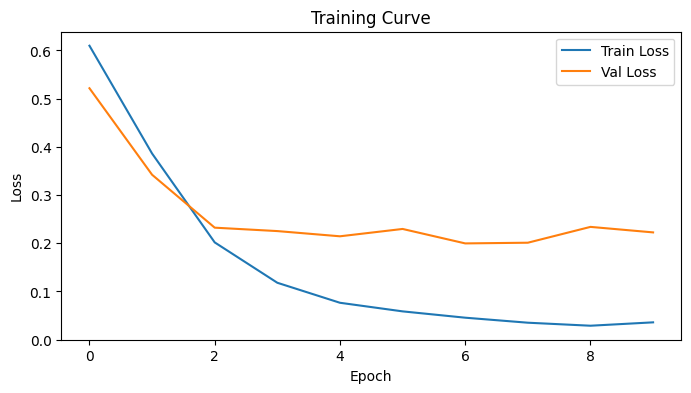

Training complete.


In [10]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

EPOCHS = 10
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.float().to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs).squeeze(), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validate
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.float().to(device)
            out = model(imgs).squeeze()
            val_loss += criterion(out, labels).item()
            preds = (torch.sigmoid(out) > 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total += labels.size(0)

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(valid_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Val Acc: {correct/total:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/best_model.pth')
        print("  - Best model saved")

# Plot loss curve
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training Curve'); plt.legend()
plt.savefig('/content/loss_curve.png')
plt.show()
print("Training complete.")

              precision    recall  f1-score   support

        Fake       0.85      0.91      0.88       100
        Real       0.90      0.84      0.87       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.87       200
weighted avg       0.88      0.88      0.87       200

ROC-AUC Score: 0.9484


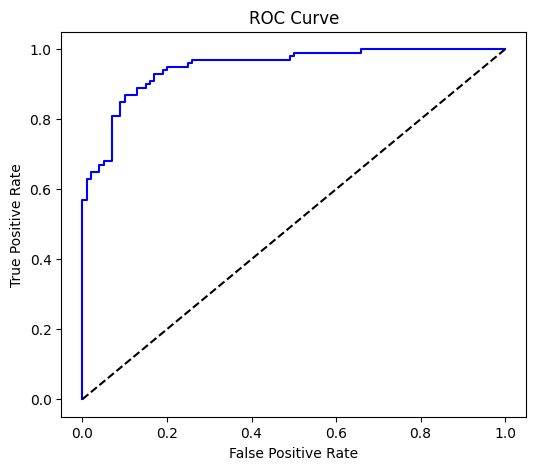

In [11]:
model.load_state_dict(torch.load('/content/best_model.pth'))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        probs = torch.sigmoid(model(imgs).squeeze()).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))
print("ROC-AUC Score:", round(roc_auc_score(all_labels, all_probs), 4))

fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.savefig('/content/roc_curve.png')
plt.show()

## **Save Streamlit App**

In [42]:
app_code = '''
import streamlit as st
import torch
import torch.nn as nn
import numpy as np
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from PIL import Image

st.set_page_config(page_title="Deepfake Detector", page_icon="🔍", layout="centered")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class AddFFTChannel:
    def __call__(self, tensor):
        gray = tensor.mean(dim=0)
        fft = torch.fft.fft2(gray)
        magnitude = torch.log(torch.abs(fft) + 1e-8)
        magnitude = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min())
        return torch.cat([tensor, magnitude.unsqueeze(0)], dim=0)

fft_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
    AddFFTChannel(),
])

@st.cache_resource
def load_model():
    m = models.efficientnet_b0(weights=None)
    old_conv = m.features[0][0]
    new_conv = nn.Conv2d(4, old_conv.out_channels,
                         kernel_size=old_conv.kernel_size,
                         stride=old_conv.stride,
                         padding=old_conv.padding,
                         bias=False)
    m.features[0][0] = new_conv
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, 1)
    m.load_state_dict(torch.load("/content/best_model.pth", map_location=device))
    m.to(device)
    m.eval()
    return m

model = load_model()
cam = GradCAM(model=model, target_layers=[model.features[-1]])

st.title(" Deepfake Detection System")
st.markdown("Upload a face image to check if it is **Real** or **Fake**")
st.divider()

uploaded_file = st.file_uploader("Upload a face image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    img = Image.open(uploaded_file).convert("RGB").resize((224, 224))
    tensor = fft_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        prob = torch.sigmoid(model(tensor)).item()

    label = "REAL" if prob > 0.5 else "FAKE"
    confidence = prob if label == "REAL" else 1 - prob

    grayscale_cam = cam(input_tensor=tensor,
                        targets=[ClassifierOutputTarget(0)])[0]
    img_np = np.array(img) / 255.0
    heatmap = show_cam_on_image(img_np.astype(np.float32),
                                grayscale_cam, use_rgb=True)

    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Original Image")
        st.image(img, use_column_width=True)
    with col2:
        st.subheader("Grad-CAM Heatmap")
        st.image(heatmap, use_column_width=True)

    st.divider()

    if label == "FAKE":
        st.error(f"🚨 Prediction: **FAKE** — {confidence*100:.1f}% confidence")
    else:
        st.success(f"✅ Prediction: **REAL** — {confidence*100:.1f}% confidence")

    st.subheader("Confidence Score")
    st.progress(int(confidence * 100))
    st.caption(f"{confidence*100:.1f}% sure this face is {label}")
'''

with open("/content/app.py", "w") as f:
    f.write(app_code)

print("✅ app.py saved!")

✅ app.py saved!


## **Launch Streamlit**

In [39]:
from google.colab import userdata
from pyngrok import ngrok

token = userdata.get("NGROK_AUTHTOKEN")
ngrok.set_auth_token(token)

In [41]:
from pyngrok import ngrok
import subprocess, time

subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(2)

# Kill any running ngrok processes to ensure a clean start
ngrok.kill()

subprocess.Popen([
    "streamlit", "run", "/content/app.py",
    "--server.port", "8501",
    "--server.headless", "true"
])
time.sleep(4)

public_url = ngrok.connect(8501)
print("=" * 40)
print("App live at:", public_url)
print("=" * 40)

App live at: NgrokTunnel: "https://vulturelike-unprecipitously-jovani.ngrok-free.dev" -> "http://localhost:8501"
